# Visualizing the Multi-Spectral Multi-Crop Dataset

This notebook produces the diagnostic and descriptive figures which we report in ** Dataset Description** and ** Spectral Data Quality** of the paper.

**Five sections:**
1. Sample-count audit (per crop, class, week, device)
2. Mean spectrum per class (one figure per crop per device)
3. Spectral progression over weeks (diseased vs healthy)
4. PCA scatter of classes per device



## 0. Setup, Uncomment to Run Base installations

## Managing imports

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from buaiir_spectra.data.dataset import *
from buaiir_spectra.preprocess.transform import Bound_Outlier_Filter, Smooth_Signal
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torchinfo import summary
import time
import pathlib
from tqdm import tqdm
from typing import List, Optional, Tuple
import warnings
warnings.filterwarnings(action="ignore")
from einops import rearrange
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [15]:
# Global font-size and default figure-size settings for every matplotlib
# plot in this notebook. Individual plotting functions that pass their own
# figsize=(...) (most of them do) will still override the default figsize
# here -- but font sizes set via rcParams apply everywhere regardless,
# since individual plots don't set font sizes themselves.
plt.rcParams.update({
    'figure.figsize': (10, 7),   # default figure size, used only when a function doesn't pass its own figsize
    'font.size': 14,             # base font size (affects anything not overridden below)
    'axes.titlesize': 18,        # subplot / figure title
    'axes.labelsize': 16,        # x/y axis labels
    'xtick.labelsize': 13,       # x tick labels
    'ytick.labelsize': 13,       # y tick labels
    'legend.fontsize': 13,       # legend text
    'figure.titlesize': 20,      # fig.suptitle()
})

In [16]:
#!unzip spectra-data.zip

## Data Loading interface

This section loads spectral data for all the three device. The API provides:

- Spectral wavelength, $x$
- Target Maxtrix $y$
- Images $\text{image}$ image for each spectral reading
- Wavelength for the device being loaded
- Support classes i.e
  
| Supported classes | Crop|
| :--- |:--|
| HLT |Cassava, Beans, Maize|
| BLB | Beans|
| BRD |Beans|
| MSV |Maize|
| MLN |Maize|
| CBB |Cassava|
| CBSD |Cassava|

- There are three device supported i.e. these were used during data collections
  |Device|
  |:--|
  |BIO_SCIENCE|
  |SCAN_CODER|
  |LOW_COST|

- The returned target, $y$ is a vector containing the following information per index
|Index| Information|
|:--|:--|
|0 | Average Titer or Elisa value|
|1 | Expert reading |
|2 | Kind of Plant|
|3| Week of collection|
|4| Class type |

In [17]:
def load_spectral(device):
    ds = SpectralDataset(
        pathlib.Path('spectra_data'),
        device=device
    )
    loader = SpectralDataLoader(ds, batch_size= len(ds), shuffle=True)
    # get all the data

    x, img, y = tqdm(next(iter(loader)))
    y = y.reset_index(drop=True)

    # filter out Titer_1, Score_1, Crop, Week and class type
    y_filtered = pd.DataFrame()

    y_filtered["avg_titer"] = y["Titer_1"]
    y_filtered["score"] = y["Score_1"]
    y_filtered["crop"] = y["Crop"]
    y_filtered["week"] = y["Week"]
    y_filtered["class"] = y["Class"]
    # y_filtered["class"] = np.where(y_filtered['class'] == 'CMD', 'CBSD', y_filtered['class'])
    

    # compute wavelength
    wavelength = ds.wavelength
    class_codes = ['HLT', 'BLB', 'BRD', 'MLN', 'MSV', 'CBSD', 'CBB']

    return x,  img, y_filtered, wavelength, class_codes


if __name__ == '__main__':
    # compute a global state once for data loading
    global_state = {}
    
    for device in Device.get_devices():
        print(f"Started on {device.name}....")
        x, images, y, wavelength, class_codes = load_spectral(device)
        global_state[device] = {
            'x': x,
            'y': y,
            'images': images,
            'wavelength': wavelength,
            'class_codes': class_codes
        }
        print(f"Done with {device.name}...")
        # testing the unique classes 
        print(y['class'].unique())

Started on BIO_SCIENCE....


100%|██████████| 3/3 [00:00<00:00, 71493.82it/s]


Done with BIO_SCIENCE...
['MSV' 'BRD' 'BLB' 'HLT' 'MLN' 'CBSD' 'CBB']
Started on SCAN_CORDER....


100%|██████████| 3/3 [00:00<00:00, 53544.31it/s]


Done with SCAN_CORDER...
['MSV' 'BRD' 'CBB' 'CBSD' 'HLT' 'BLB' 'MLN']
Started on LOW_COST....


100%|██████████| 3/3 [00:00<00:00, 59353.36it/s]

Done with LOW_COST...
['MSV' 'CBSD' 'HLT' 'BRD' 'MLN' 'CBB' 'BLB']


## Generating Spectral Counts

In [18]:
CROP_NAMES = {'B': 0 , 'M': 1, 'C':2}

def load_device(device, with_images=False):
    """
    Loads data for a single device
    """
    state_idx = global_state[device]
    x, images, y,  wl, class_codes = (
        state_idx['x'],
        state_idx['images'],
        state_idx['y'],
        state_idx['wavelength'],
        state_idx['class_codes']
    )
    #  correct indices    

    if with_images:
        return x, images, y, wl, class_codes
    return x, y, wl, class_codes

def y_to_df(y, class_codes):
    """
    Convert the y labels inot 
    """
    columns = ['avg_titer', 'score','crop', 'week', 'class']
    code_dict = dict(enumerate(class_codes))
    df = pd.DataFrame(data=y, columns=columns)
    df['crop'] = df['crop'].map(CROP_NAMES)
    return df

if __name__ == '__main__':
    x, y, wl, class_codes = load_device(Device.LOW_COST)
    print(y.shape)
    y_df = y_to_df(y, class_codes)
    print(f'\nSample of y features: \n', '*'*60, y_df.head(10), sep='\n')
    print(f'\nSample Dimensions for LOW_COST only', '*'*80, sep='\n')
    print(x.shape, y.shape, len(wl), class_codes, sep= ' | ')

(3690, 5)

Sample of y features: 

************************************************************
   avg_titer  score  crop  week class
0  24.276200    3.0     1    12   MSV
1  24.276200    3.0     1    12   MSV
2  16.309230    4.0     2     9  CBSD
3  16.309230    4.0     2     9  CBSD
4  37.354535    1.0     1     6   HLT
5  37.354535    1.0     1     6   HLT
6  35.573530    1.0     1    12   HLT
7  35.573530    1.0     1    12   HLT
8  35.826352    1.0     1    10   HLT
9  35.826352    1.0     1    10   HLT

Sample Dimensions for LOW_COST only
********************************************************************************
(3690, 381) | (3690, 5) | 381 | ['HLT', 'BLB', 'BRD', 'MLN', 'MSV', 'CBSD', 'CBB']


In [19]:
# for device in global_state:
#     state = global_state[device]
#     y = state['y']
    
#     # Update the 'class' column directly inside the DataFrame
#     y['class'] = np.where(y['class'] == 'CMD', 'CBSD', y['class'])
    
#     # Investigate the new unique labels
#     global_state[device]['y']['class'] = y['class'].values
#     unique_classes = y['class'].unique() # Added missing ()
#     print(device.name, end=": ")
#     print(unique_classes)

## Data Audit 

The generated audit addresses the following questions:
- How many weeks of data were collected per crop for each device?
- How many expert readings were recorded per crop?
- How many titer or ELISA readings were recorded per crop?

In [20]:
def compute_data_audits(device):
    x, y, wl, class_codes = load_device(device)
    # y = y.fillna(0)
    # fill nan with zeros
    
    columns, stat_coll = [], []
    n_titer, n_expert = [], []
    counts = []
    for i, class_code in enumerate(class_codes):
        if i == 0:
            for plant_code in CROP_NAMES.keys():
                mask = (y.iloc[:, -3] == plant_code) & (y.iloc[:, -1] == class_code)
                filtered = y[mask]
                # spectral count
                x_masked = x[mask]
                count = x_masked.shape[0]
                
                unique_weeks = np.unique(filtered.iloc[:, -2]).astype(np.int32)
                label = f'{plant_code}_{class_code}'
                columns.append(label)
                stat_coll.append(unique_weeks)
                no_expert_readings = np.sum(~np.isnan(filtered.iloc[:, 1]))
                no_titer_readings = np.sum(~np.isnan(filtered.iloc[:, 0]))
                n_titer.append(no_titer_readings)
                n_expert.append(no_expert_readings)
                counts.append(count)
                

        else:
            mask = y.iloc[:, -1] == class_code
            filtered = y[mask]
            # spectral count
            x_masked = x[mask]
            count = x_masked.shape[0]
            
            unique_weeks = np.unique(filtered.iloc[:, -2]).astype(np.int32)
            no_expert_readings = np.sum(~np.isnan(filtered.iloc[:, 1]))
            no_titer_readings = np.sum(~np.isnan(filtered.iloc[:, 0]))
            stat_coll.append(unique_weeks)
            columns.append(class_code)
            n_titer.append(no_titer_readings)
            n_expert.append(no_expert_readings)
            counts.append(count)
        
    return stat_coll, columns, n_titer, n_expert, counts

if __name__ == '__main__':
    global_stat = []
    device_coll = []
    disease_classes= []
    expert_scores = []
    titer_scores = []
    counts_all = []
    for device in Device.get_devices():
        states, columns, n_titer, n_expert, n_counts = compute_data_audits(device)
        for sub_state, col, titer_count, expert_count, count in zip(states, columns, n_titer, n_expert, n_counts):
            global_stat.append(sub_state)
            device_coll.append(device.name)
            disease_classes.append(col)
            titer_scores.append(titer_count)
            expert_scores.append(expert_count)
            counts_all.append(count)
    
    stat_df= pd.DataFrame()
    stat_df['Device'] = device_coll
    stat_df['Class'] = disease_classes
    stat_df['unique_weeks'] = global_stat
    stat_df['no_titer_readings'] = titer_scores
    stat_df['no_expert_readings'] = expert_scores
    stat_df['spectral']  = counts_all
    
    
stat_df.to_csv('current_data_card.csv')
stat_df

,Device,Class,unique_weeks,no_titer_readings,no_expert_readings,spectral
0,BIO_SCIENCE,B_HLT,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",337,337,337
1,BIO_SCIENCE,M_HLT,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",451,451,451
2,BIO_SCIENCE,C_HLT,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",458,458,458
3,BIO_SCIENCE,BLB,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",330,330,330
4,BIO_SCIENCE,BRD,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",336,336,336
5,BIO_SCIENCE,MLN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",475,475,475
6,BIO_SCIENCE,MSV,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",467,467,467
7,BIO_SCIENCE,CBSD,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",469,469,469
8,BIO_SCIENCE,CBB,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",450,450,465
9,SCAN_CORDER,B_HLT,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",494,494,494


## 2. Mean spectrum per class (one figure per crop per device)

Compute the mean progression of each disease class per week

TODO:
- Search for better approaches to visualize disease progression in spectral data
- One a weeks basis for all devices 

In [21]:
# standardizes crop and disease class namings
# (same implementation as the transform_y defined later in the notebook,
# duplicated here so this section can run standalone, earlier in the notebook)
def transform_y(y: pd.DataFrame, class_codes: List[str]):
    # remove nans
    y_sub = y.fillna(0)

    # build class code
    class_codes = {code: i for i, code in enumerate(class_codes)}
    crop_codes = {'B': 0, 'M': 1, 'C': 2}

    # perform data mapping
    y_sub.iloc[:, -1] = y_sub.iloc[:, -1].map(class_codes)
    y_sub.iloc[:, -3] = y_sub.iloc[:, -3].map(crop_codes)

    # convert to array
    return y_sub.to_numpy().astype(np.int32)


# Fixed class -> color mapping so each disease class keeps the SAME color
# across every plot in this notebook (e.g. HLT is always green).
CLASS_COLOR_MAP = {
    'HLT': 'green',
    'BLB': 'tab:orange',
    'BRD': 'tab:blue',
    'MLN': 'tab:purple',
    'MSV': 'tab:brown',
    'CMD': 'tab:pink',
    'CBB': 'tab:gray',
}

CROP_FULL_NAMES = {'B': 'Beans', 'M': 'Maize', 'C': 'Cassava'}

# Outlier bounds -- only known-good for SCAN_CORDER (same bounds already
# used elsewhere in this notebook, e.g. generate_crop_clusters /
# cluster_by_crops). BIO_SCIENCE and LOW_COST are left unfiltered here
# since their bounds haven't been validated.
OUTLIER_BOUNDS = {
    Device.SCAN_CORDER: (-1.5, 5.0),
}

def apply_outlier_filter(device, x, y):
    """Applies Bound_Outlier_Filter only for devices with known-good bounds."""
    bounds = OUTLIER_BOUNDS.get(device)
    if bounds is None:
        return x, y
    bf = Bound_Outlier_Filter(*bounds)
    return bf.forward(x, y)


# Manufacturer-rated wavelength range for BIO_SCIENCE (CI-710); trims off
# the region below 400nm outside its calibrated window.
DEVICE_WAVELENGTH_BOUNDS = {
    Device.BIO_SCIENCE: (400, 1042),
}

def trim_to_calibrated_range(device, x, wl):
    """Drops spectral columns outside a device's manufacturer-rated
    wavelength range. No-op for devices not in DEVICE_WAVELENGTH_BOUNDS."""
    bounds = DEVICE_WAVELENGTH_BOUNDS.get(device)
    if bounds is None:
        return x, wl
    lo, hi = bounds
    wl_arr = np.asarray(wl)
    mask = (wl_arr >= lo) & (wl_arr <= hi)
    return x[:, mask], wl_arr[mask]


def compute_mean_spectrum(device):
    """
    Computes the mean spectrum (mean reflectance per wavelength) for every
    disease class, split out per crop. Applies outlier filtering (device-
    aware, SCAN_CORDER only for now) and wavelength trimming (BIO_SCIENCE
    only for now) before averaging.
    Returns: ({crop_letter: {class_name: mean_spectrum_array}}, wl)
    """
    x, y, wl, class_codes = load_device(device)
    y = transform_y(y, class_codes)  # convert crop/class columns to numeric codes
    x, y = apply_outlier_filter(device, x, y)
    x, wl = trim_to_calibrated_range(device, x, wl)
    crop_name_list = list(CROP_NAMES.keys())

    result = {crop: {} for crop in crop_name_list}
    for crop_letter, crop_val in CROP_NAMES.items():
        for i, code in enumerate(class_codes):
            mask = (y[:, -3] == crop_val) & (y[:, -1] == i)
            x_filtered = x[mask]
            if x_filtered.shape[0] == 0 or np.isnan(x_filtered).all():
                continue
            result[crop_letter][code] = np.nanmean(x_filtered, axis=0)
    return result, wl


def plot_mean_spectrum_per_class(device, out_dir="."):
    """
    One figure per device, one subplot per crop (Beans, Maize, Cassava),
    each subplot showing the mean spectrum for every disease class present
    for that crop, colored consistently via CLASS_COLOR_MAP.
    Saved to: {out_dir}/{device.name}_mean_spectrum_per_class.png
    """
    mean_spectra, wl = compute_mean_spectrum(device)
    crop_name_list = list(CROP_NAMES.keys())

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax = ax.flatten()

    for i, crop in enumerate(crop_name_list):
        for class_name, spectrum in mean_spectra[crop].items():
            if class_name not in CLASS_COLOR_MAP:
                print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
            ax[i].plot(
                wl, spectrum,
                label=class_name,
                color=CLASS_COLOR_MAP.get(class_name, 'gray')
            )
        ax[i].set_title(f'{CROP_FULL_NAMES[crop]} - mean spectrum per class')
        ax[i].set_xlabel('Wavelength'); ax[i].set_ylabel('Mean Reflectance')
        ax[i].legend(frameon=True, loc='best')

    fig.suptitle(f'Mean Spectrum per Class - {device.name}', fontsize=16, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = f"{out_dir}/{device.name}_mean_spectrum_per_class.png"
    fig.savefig(out_path, dpi=300)
    print(f"Saved mean spectrum figure -> {os.path.abspath(out_path)}")
    plt.show()


def plot_all_devices_mean_spectrum(out_dir="."):
    """
    ONE figure with every device x crop combination of mean spectrum per
    disease class:
    rows = devices (BIO_SCIENCE, SCAN_CORDER, LOW_COST)
    cols = crops   (Beans, Maize, Cassava)
    Saved to: {out_dir}/all_devices_mean_spectrum_combined.png
    """
    devices = Device.get_devices()
    crop_name_list = list(CROP_NAMES.keys())

    fig, ax = plt.subplots(len(devices), len(crop_name_list), figsize=(6 * len(crop_name_list), 5 * len(devices)))

    for row, device in enumerate(devices):
        mean_spectra, wl = compute_mean_spectrum(device)

        for col, crop in enumerate(crop_name_list):
            axis = ax[row][col]
            for class_name, spectrum in mean_spectra[crop].items():
                if class_name not in CLASS_COLOR_MAP:
                    print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
                axis.plot(
                    wl, spectrum,
                    label=class_name,
                    color=CLASS_COLOR_MAP.get(class_name, 'gray')
                )
            axis.set_title(f'{CROP_FULL_NAMES[crop]} - {device.name}')
            axis.set_xlabel('Wavelength'); axis.set_ylabel('Mean Reflectance')
            axis.legend(frameon=True, loc='best')

    fig.suptitle('Mean Spectrum per Class: All Devices x All Crops', fontsize=16, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = f"{out_dir}/all_devices_mean_spectrum_combined.png"
    fig.savefig(out_path, dpi=300)
    print(f"Saved all-devices mean spectrum figure -> {os.path.abspath(out_path)}")
    plt.show()

Saved mean spectrum figure -> /home/jovyan/spaces/BIO_SCIENCE_mean_spectrum_per_class.png


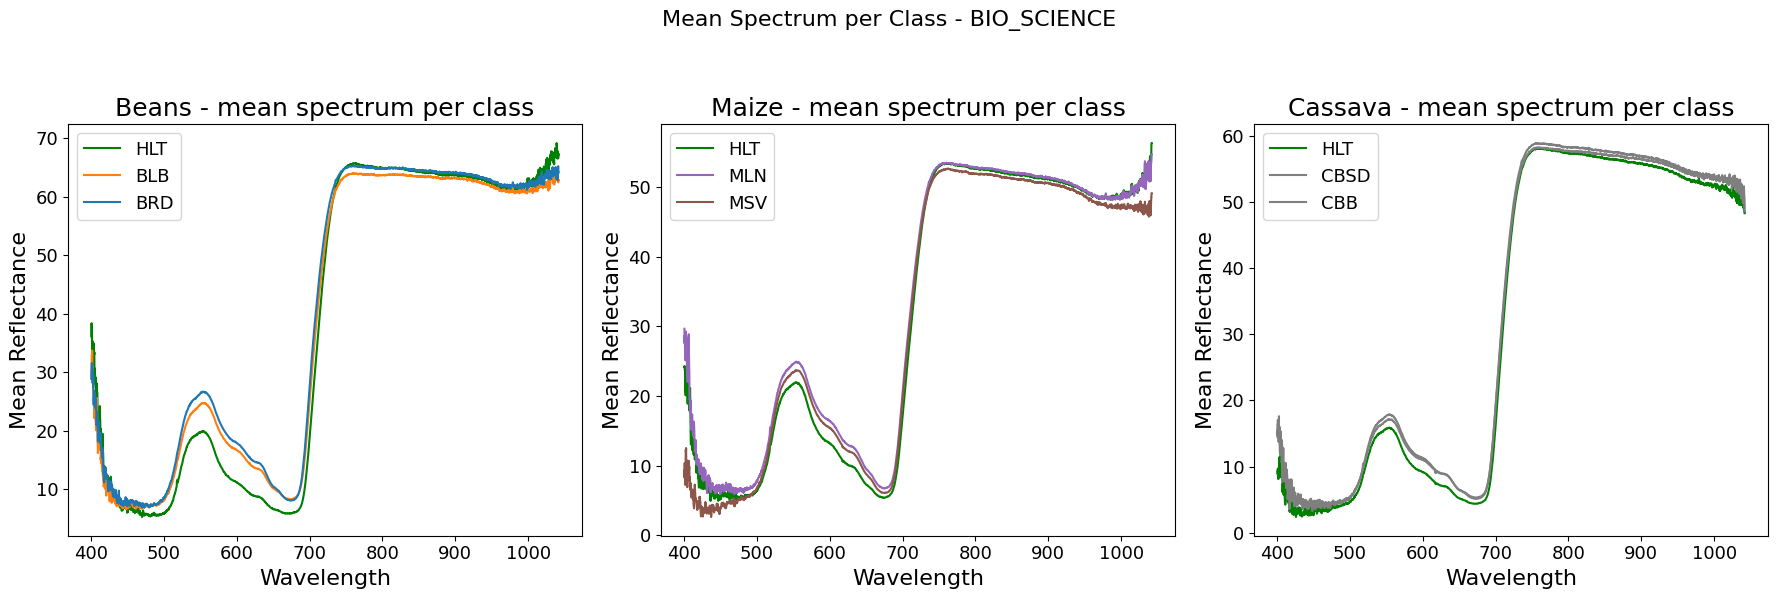

Saved disease progression figure -> /home/jovyan/spaces/BIO_SCIENCE_disease_progression.png


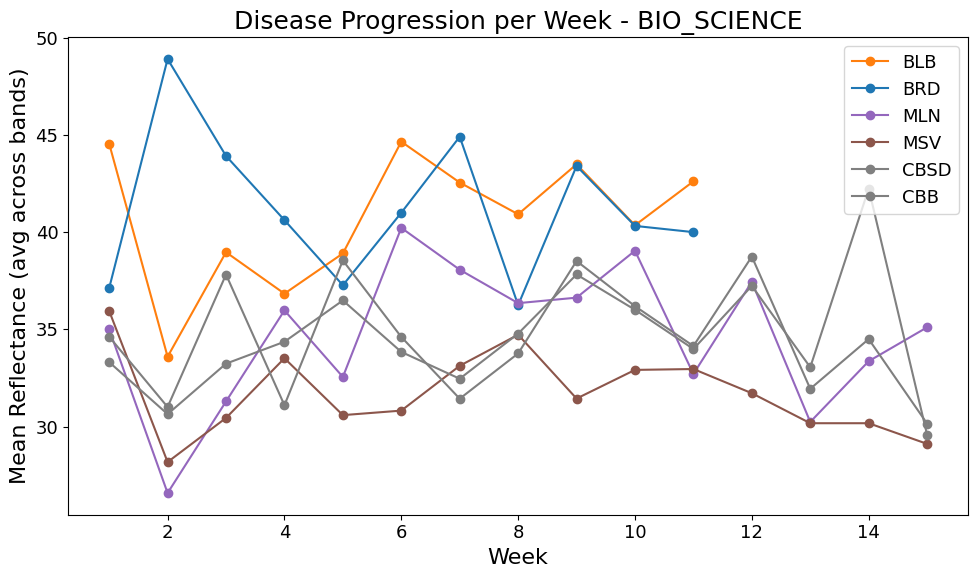

Saved mean spectrum figure -> /home/jovyan/spaces/SCAN_CORDER_mean_spectrum_per_class.png


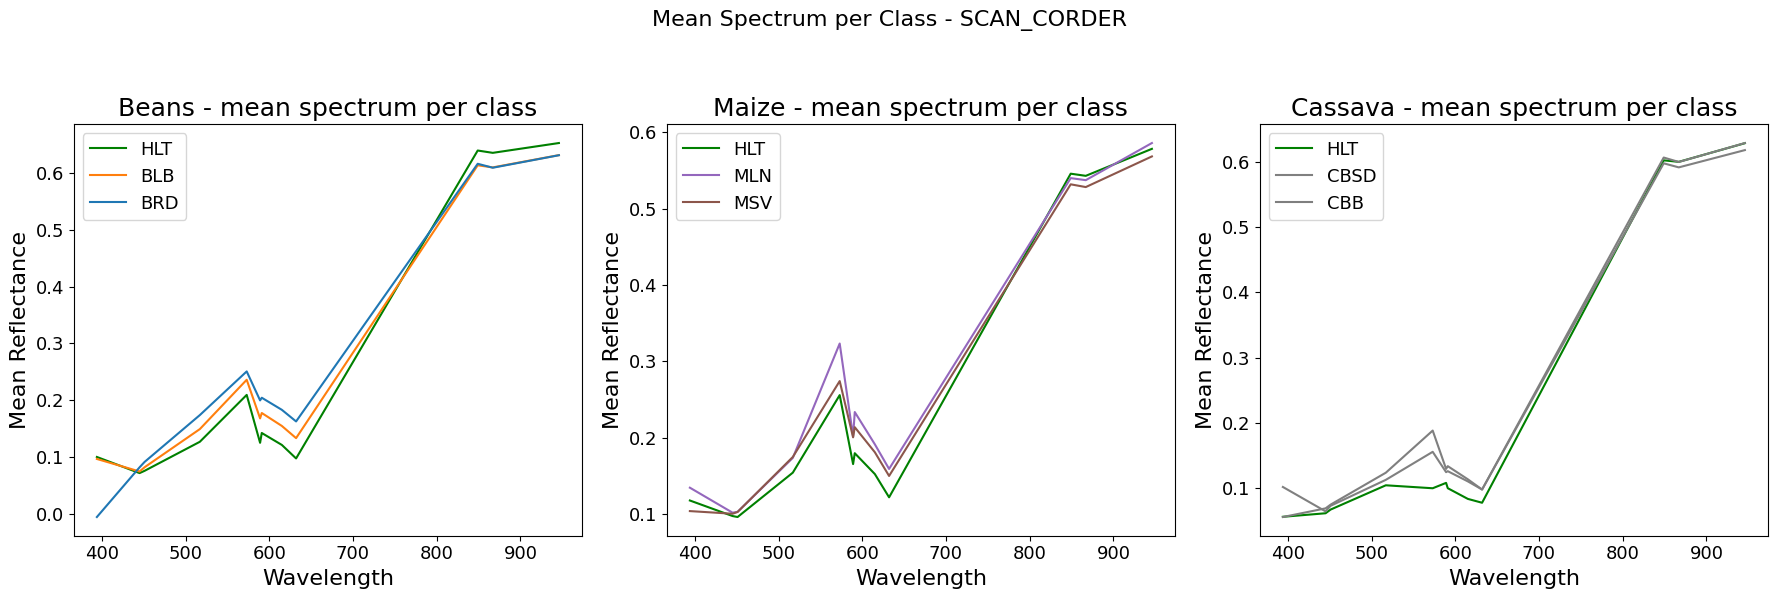

Saved disease progression figure -> /home/jovyan/spaces/SCAN_CORDER_disease_progression.png


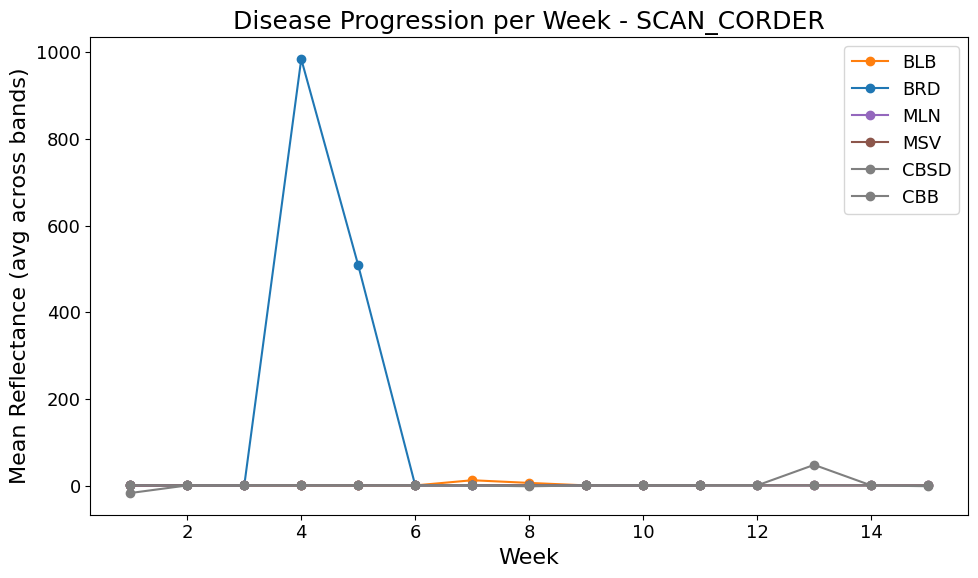

Saved mean spectrum figure -> /home/jovyan/spaces/LOW_COST_mean_spectrum_per_class.png


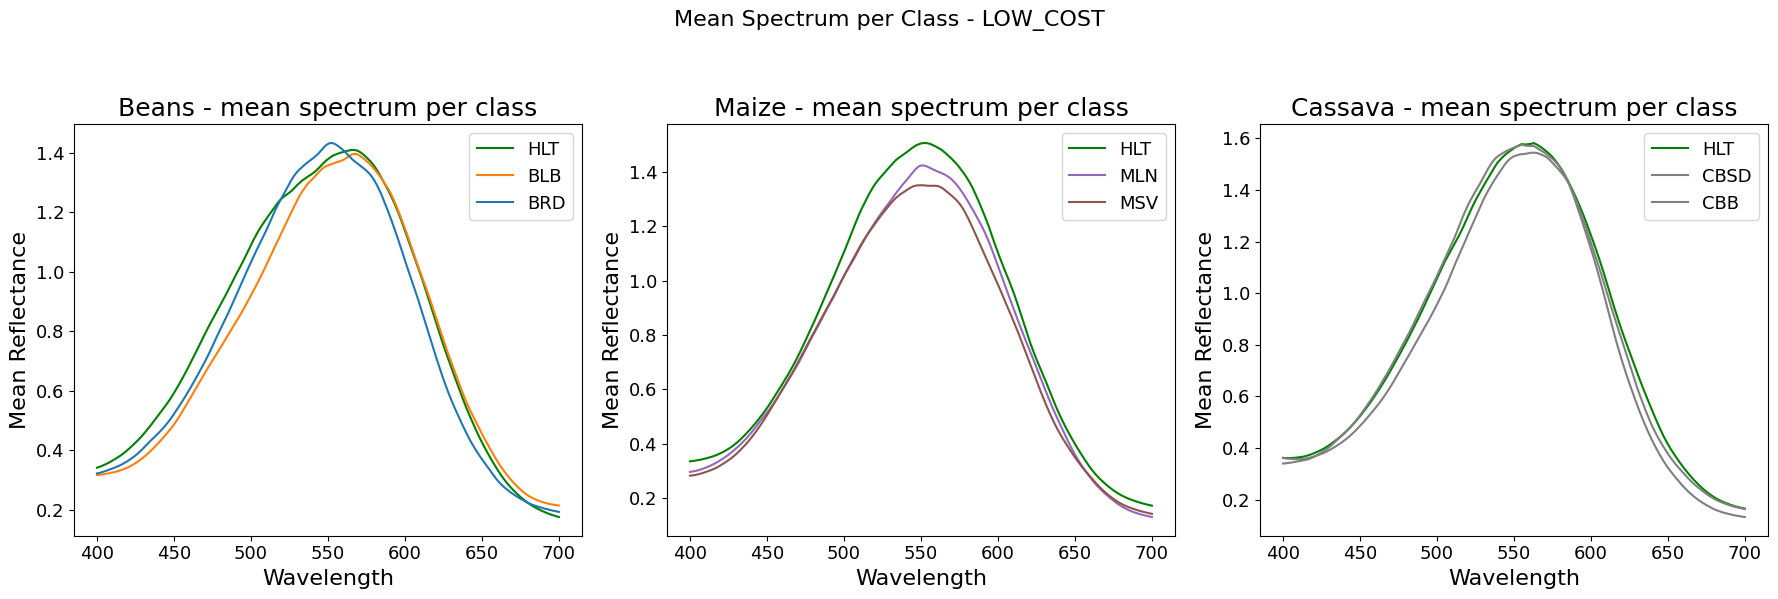

Saved disease progression figure -> /home/jovyan/spaces/LOW_COST_disease_progression.png


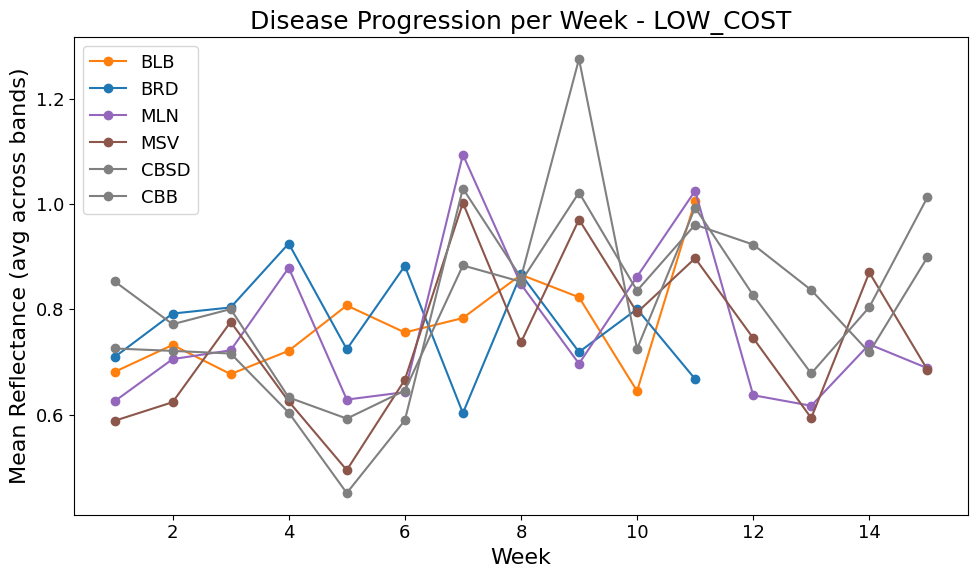

Saved all-devices mean spectrum figure -> /home/jovyan/spaces/all_devices_mean_spectrum_combined.png


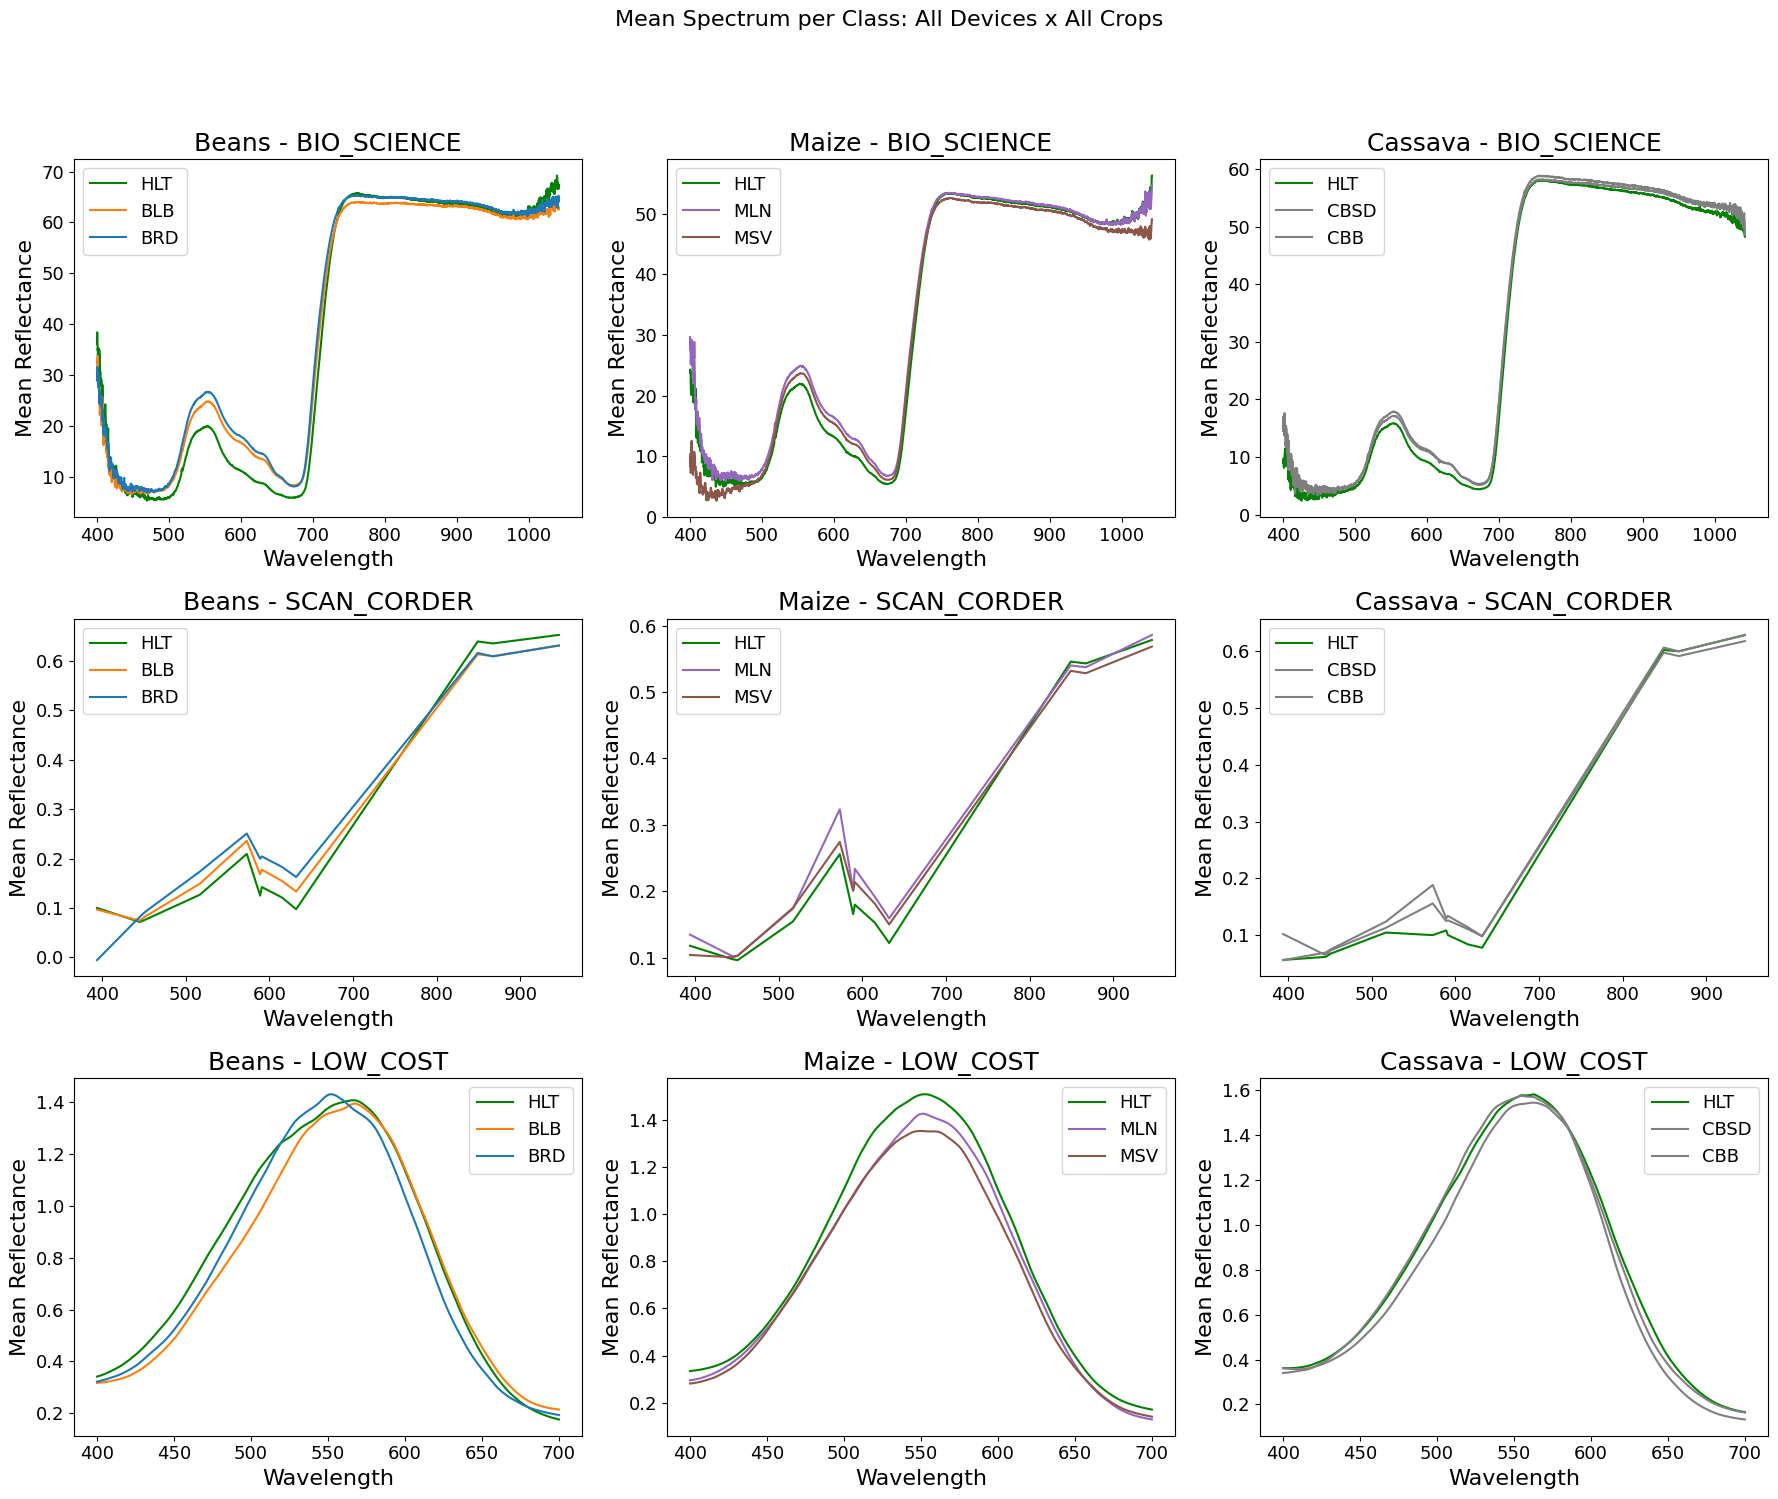

Saved all-devices disease progression figure -> /home/jovyan/spaces/all_devices_disease_progression_combined.png


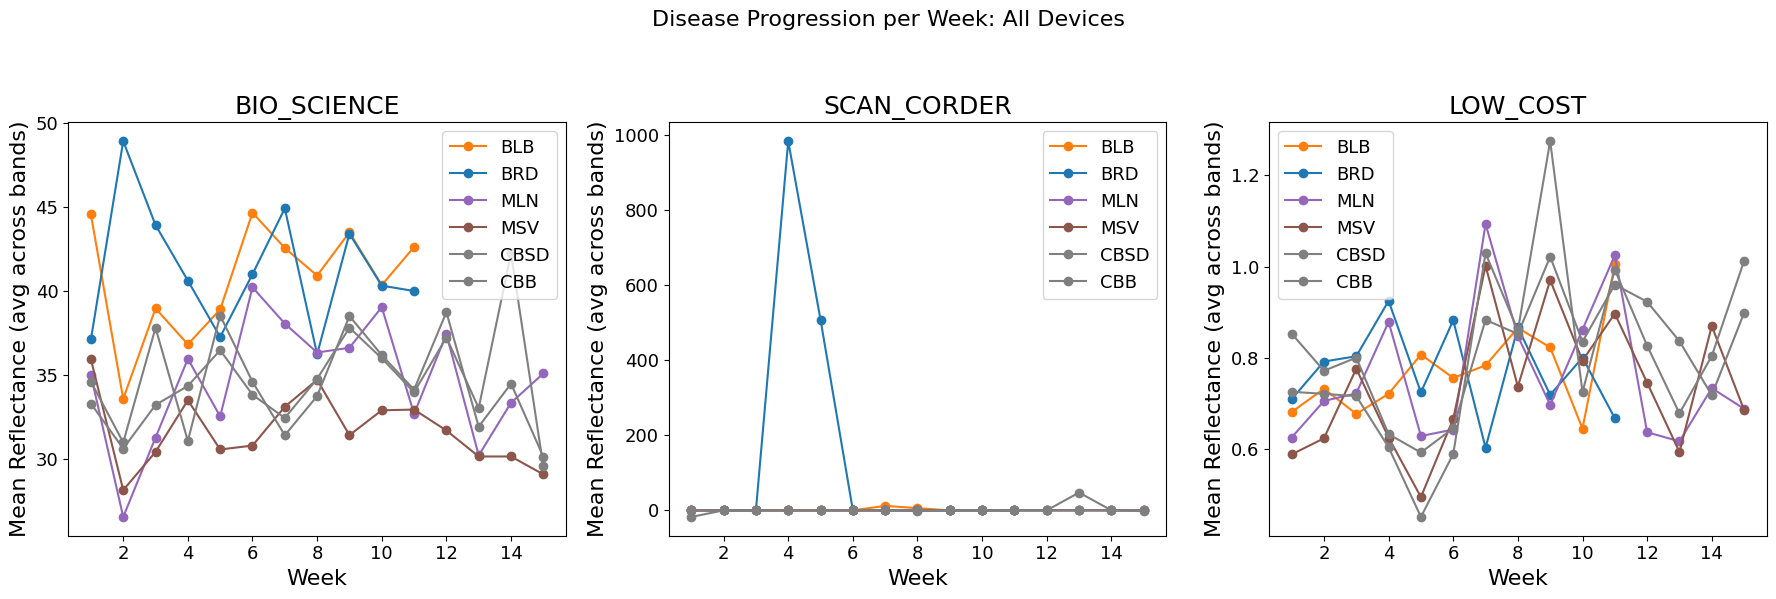

In [22]:
def compute_weekly_agg(device):
    x, y, wl, class_codes = load_device(device)
    y = transform_y(y, class_codes)  # convert crop/class columns to numeric codes

    # disease progression of the disease variants
    progress_coll = {}
    weeks = []
    for i, code in enumerate(class_codes):
        if i == 0:
            continue
        unique_weeks = np.unique(y[:, -2])
        spectral_means = []
        weeks = []
        for week in unique_weeks:
            # filter data for that weeks
            week_mask = (y[:, -2] == week) & (y[:, -1] == i)
            x_filtered = x[week_mask]
            if np.isnan(x_filtered).all():
                continue
            mean_idx = x_filtered.mean(axis=0)
            weeks.append(week)
            spectral_means.append(mean_idx)
        progress_coll[code] = {'spectral': spectral_means, 'weeks': weeks, 'wl': wl }
    
    return progress_coll


def plot_disease_progression(device, out_dir="."):
    """
    Plots the mean disease progression per week for each disease class:
    each week's mean spectrum (from compute_weekly_agg) is reduced to a
    single scalar (mean reflectance across all bands), then plotted
    against week. HLT (healthy) is excluded, matching compute_weekly_agg,
    which only tracks the disease variants.
    Saved to: {out_dir}/{device.name}_disease_progression.png
    """
    progress_coll = compute_weekly_agg(device)

    fig, ax = plt.subplots(figsize=(10, 6))
    for class_name, state in progress_coll.items():
        weeks = state['weeks']
        spectral_means = state['spectral']
        if len(weeks) == 0:
            continue
        # reduce each week's mean spectrum to a single scalar so progression
        # can be plotted on a simple week-by-week line
        weekly_scalar = [np.nanmean(s) for s in spectral_means]
        if class_name not in CLASS_COLOR_MAP:
            print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
        ax.plot(
            weeks, weekly_scalar,
            marker='o',
            label=class_name,
            color=CLASS_COLOR_MAP.get(class_name, 'gray')
        )

    ax.set_title(f'Disease Progression per Week - {device.name}')
    ax.set_xlabel('Week'); ax.set_ylabel('Mean Reflectance (avg across bands)')
    ax.legend(frameon=True, loc='best')
    fig.tight_layout()
    out_path = f"{out_dir}/{device.name}_disease_progression.png"
    fig.savefig(out_path, dpi=300)
    print(f"Saved disease progression figure -> {os.path.abspath(out_path)}")
    plt.show()


def plot_all_devices_disease_progression(out_dir="."):
    """
    ONE figure with disease progression per week for every device:
    one subplot per device (BIO_SCIENCE, SCAN_CORDER, LOW_COST), each
    showing the mean-reflectance-per-week line for every disease class.
    Saved to: {out_dir}/all_devices_disease_progression_combined.png
    """
    devices = Device.get_devices()
    fig, ax = plt.subplots(1, len(devices), figsize=(6 * len(devices), 6))
    ax = ax.flatten()

    for i, device in enumerate(devices):
        progress_coll = compute_weekly_agg(device)
        axis = ax[i]
        for class_name, state in progress_coll.items():
            weeks = state['weeks']
            spectral_means = state['spectral']
            if len(weeks) == 0:
                continue
            weekly_scalar = [np.nanmean(s) for s in spectral_means]
            if class_name not in CLASS_COLOR_MAP:
                print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
            axis.plot(
                weeks, weekly_scalar,
                marker='o',
                label=class_name,
                color=CLASS_COLOR_MAP.get(class_name, 'gray')
            )
        axis.set_title(device.name)
        axis.set_xlabel('Week'); axis.set_ylabel('Mean Reflectance (avg across bands)')
        axis.legend(frameon=True, loc='best')

    fig.suptitle('Disease Progression per Week: All Devices', fontsize=16, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = f"{out_dir}/all_devices_disease_progression_combined.png"
    fig.savefig(out_path, dpi=300)
    print(f"Saved all-devices disease progression figure -> {os.path.abspath(out_path)}")
    plt.show()


if __name__ == '__main__':
    for device in Device.get_devices():
        plot_mean_spectrum_per_class(device)
        plot_disease_progression(device)
    plot_all_devices_mean_spectrum()
    plot_all_devices_disease_progression()

## 4. PCA Scatter per crop per device

Visualize the clusters by crop type for each of the three devices.


In [23]:
# standardizes crop and disease class namings
def transform_y(y: pd.DataFrame, class_codes: List[str]):
    # remove nans
    y_sub = y.fillna(0)
    
    # build class code 
    class_codes = {code: i for i, code in enumerate(class_codes)}
    crop_codes = {'B': 0, 'M': 1, 'C': 2}
    
    # perform data mapping
    y_sub.iloc[:, -1] = y_sub.iloc[:, -1].map(class_codes)
    y_sub.iloc[:, -3] = y_sub.iloc[:, -3].map(crop_codes)
    
    # convert to array
    return y_sub.to_numpy().astype(np.int32)

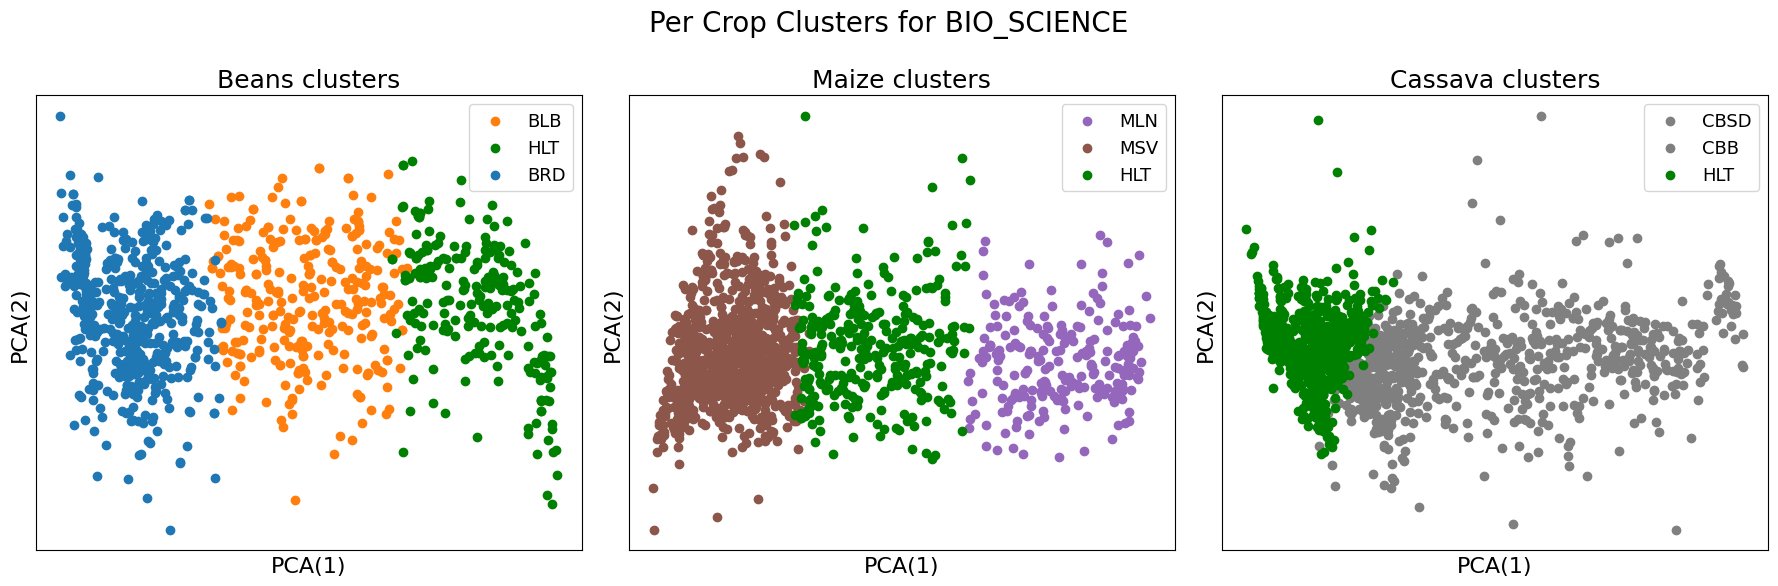

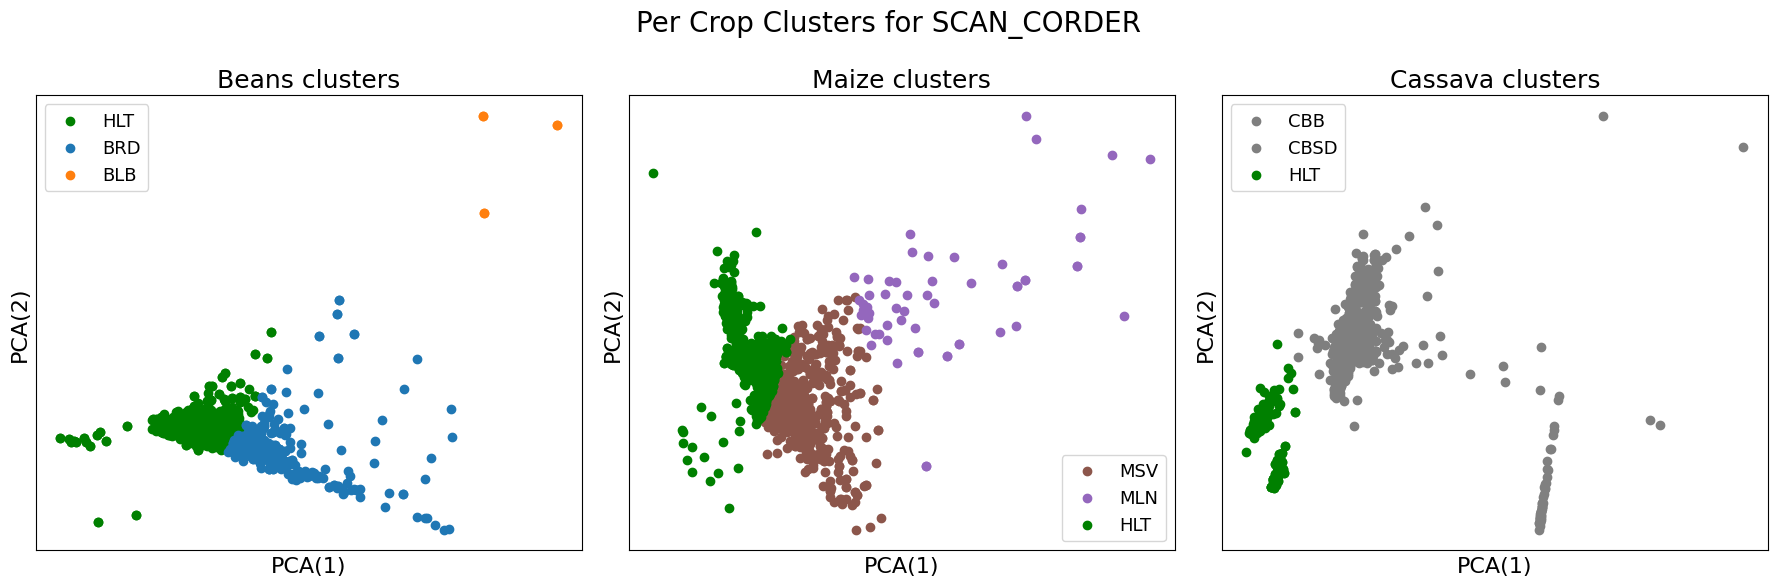

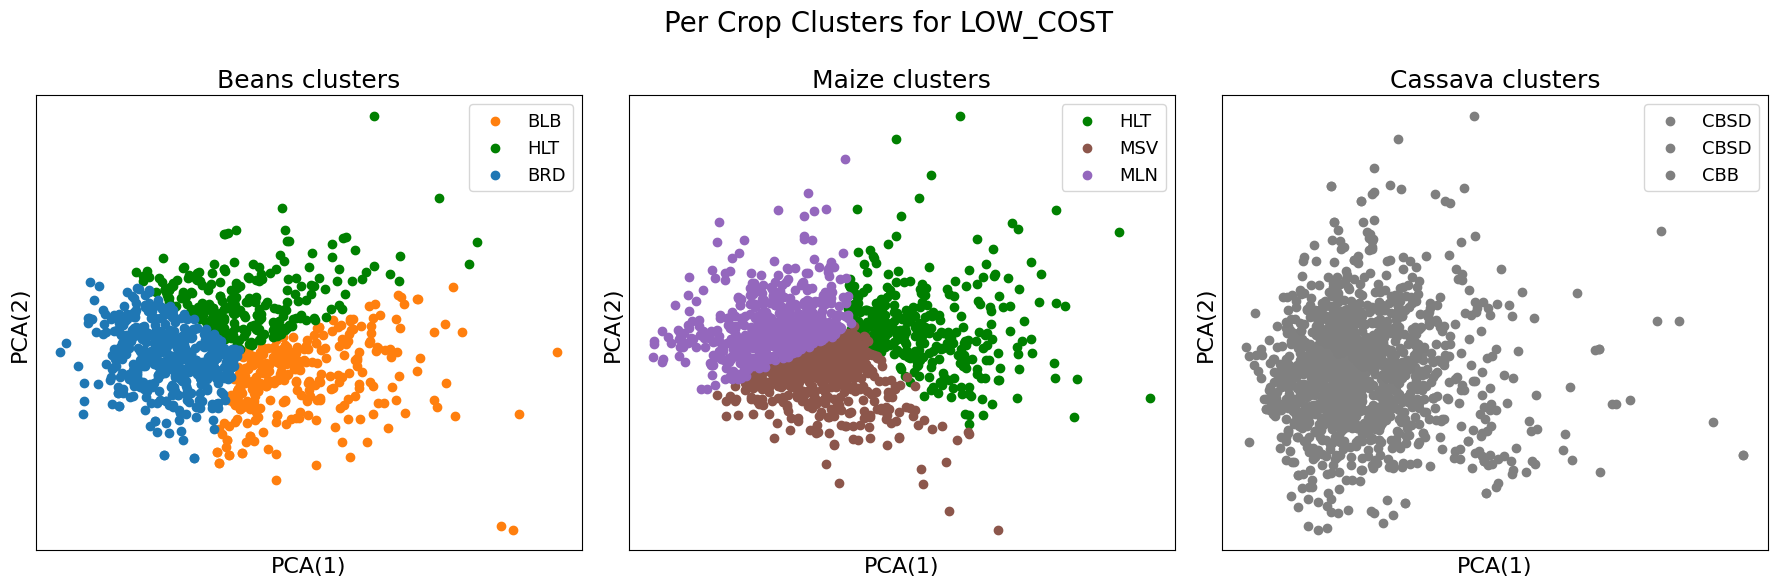

In [24]:
def generate_crop_clusters(device):
    x, y, wl, class_codes = load_device(device)
    y = transform_y(y, class_codes)
    global class_codes_dict
    class_codes_dict = {i: disease for i, disease in enumerate(class_codes)}
    
    if device == Device.SCAN_CORDER:
        bf = Bound_Outlier_Filter(-0.5, 2.0)
        x, y = bf.forward(x, y)
        # closing becoming

    cluster_state = {}
    
    # changed to crop values to pull out the numbers
    for crop in CROP_NAMES.values():
        crop_mask = (y[:, -3] == crop)
        x_data = x[crop_mask]
        y_data = y[crop_mask]
        
        # switch random state
        smote_seed = 2 if device == Device.SCAN_CORDER else 42
        smote = SMOTE(random_state=smote_seed)
        x_balanced, true_classes_balanced = smote.fit_resample(x_data, y_data[: , -1])
        
        unique_classes = len(np.unique(true_classes_balanced))
        if not unique_classes == 3:
            unique_classes -= 1

        kmeans = KMeans(n_clusters= unique_classes, random_state=42, max_iter=500,  tol=1e-5)
        kmeans.fit(x_balanced)
        
        
        
        pca= PCA(n_components= 2, random_state=42)
        x_pca = pca.fit_transform(x_balanced)
        

        cluster_state[crop] = {'pcas': x_pca, 'labels': kmeans.labels_, 'true_classes': true_classes_balanced}
    return cluster_state

# Fixed class -> color mapping so each disease class keeps the SAME color
# across every crop and every device (e.g. HLT is always green).
# .get(..., 'gray') fallback: an unexpected class name plots gray instead
# of crashing the whole run, so you can spot naming mismatches easily.
CLASS_COLOR_MAP = {
    'HLT': 'green',
    'BLB': 'tab:orange',
    'BRD': 'tab:blue',
    'MLN': 'tab:purple',
    'MSV': 'tab:brown',
    'CMD': 'tab:pink',
    'CBB': 'tab:gray',
}

##


def generate_plot(device):
    cluster_state = generate_crop_clusters(device)
    
    # restore for 3 plots
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax = ax.flatten()
    # reference name map
    crop_name_list = list(CROP_NAMES.keys())
    CROP_FULL_NAMES = {'B': 'Beans', 'M': 'Maize', 'C': 'Cassava'}

    for i, crop in enumerate(cluster_state.keys()):
        state = cluster_state[crop]
        x_pca = state['pcas']
        labels = state['labels']
        true_labels= state['true_classes']
        
        # compute the right clusters
        cluster_dict = {}
        unique_labels = np.unique(labels)
        for label in unique_labels:
            mask_idx = (labels == label)
            pred_classes = true_labels[mask_idx]
            majority_class = Counter(pred_classes).most_common(1)[0][0]
            cluster_dict[label] = majority_class.astype(np.int32)            

        
        unique_labels = np.unique(labels)
        for label in unique_labels:
            cluster_mask = (labels == label)
            class_name = class_codes_dict[cluster_dict[label]]
            if class_name not in CLASS_COLOR_MAP:
                print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
            ax[i].scatter(
                x_pca[cluster_mask, 0], x_pca[cluster_mask, 1],
                label=class_name,
                color=CLASS_COLOR_MAP.get(class_name, 'gray')
            )
        ax[i].set_title(f'{CROP_FULL_NAMES[crop_name_list[crop]]} clusters')
        ax[i].set_xlabel('PCA(1)'); ax[i].set_ylabel('PCA(2)')
        ax[i].legend(frameon=True, loc='best')
        ax[i].set_xticks([])
        ax[i].set_yticks([])
    
        
    fig.suptitle(f'Per Crop Clusters for {device.name}')
    plt.tight_layout()
    plt.savefig(f"{device.name}_pca_clusters.png")
    plt.show()
    


if __name__ == '__main__':
    for device in Device.get_devices():
        generate_plot(device)

Saved all-devices combined figure -> /home/jovyan/spaces/all_devices_pca_clusters_combined.png


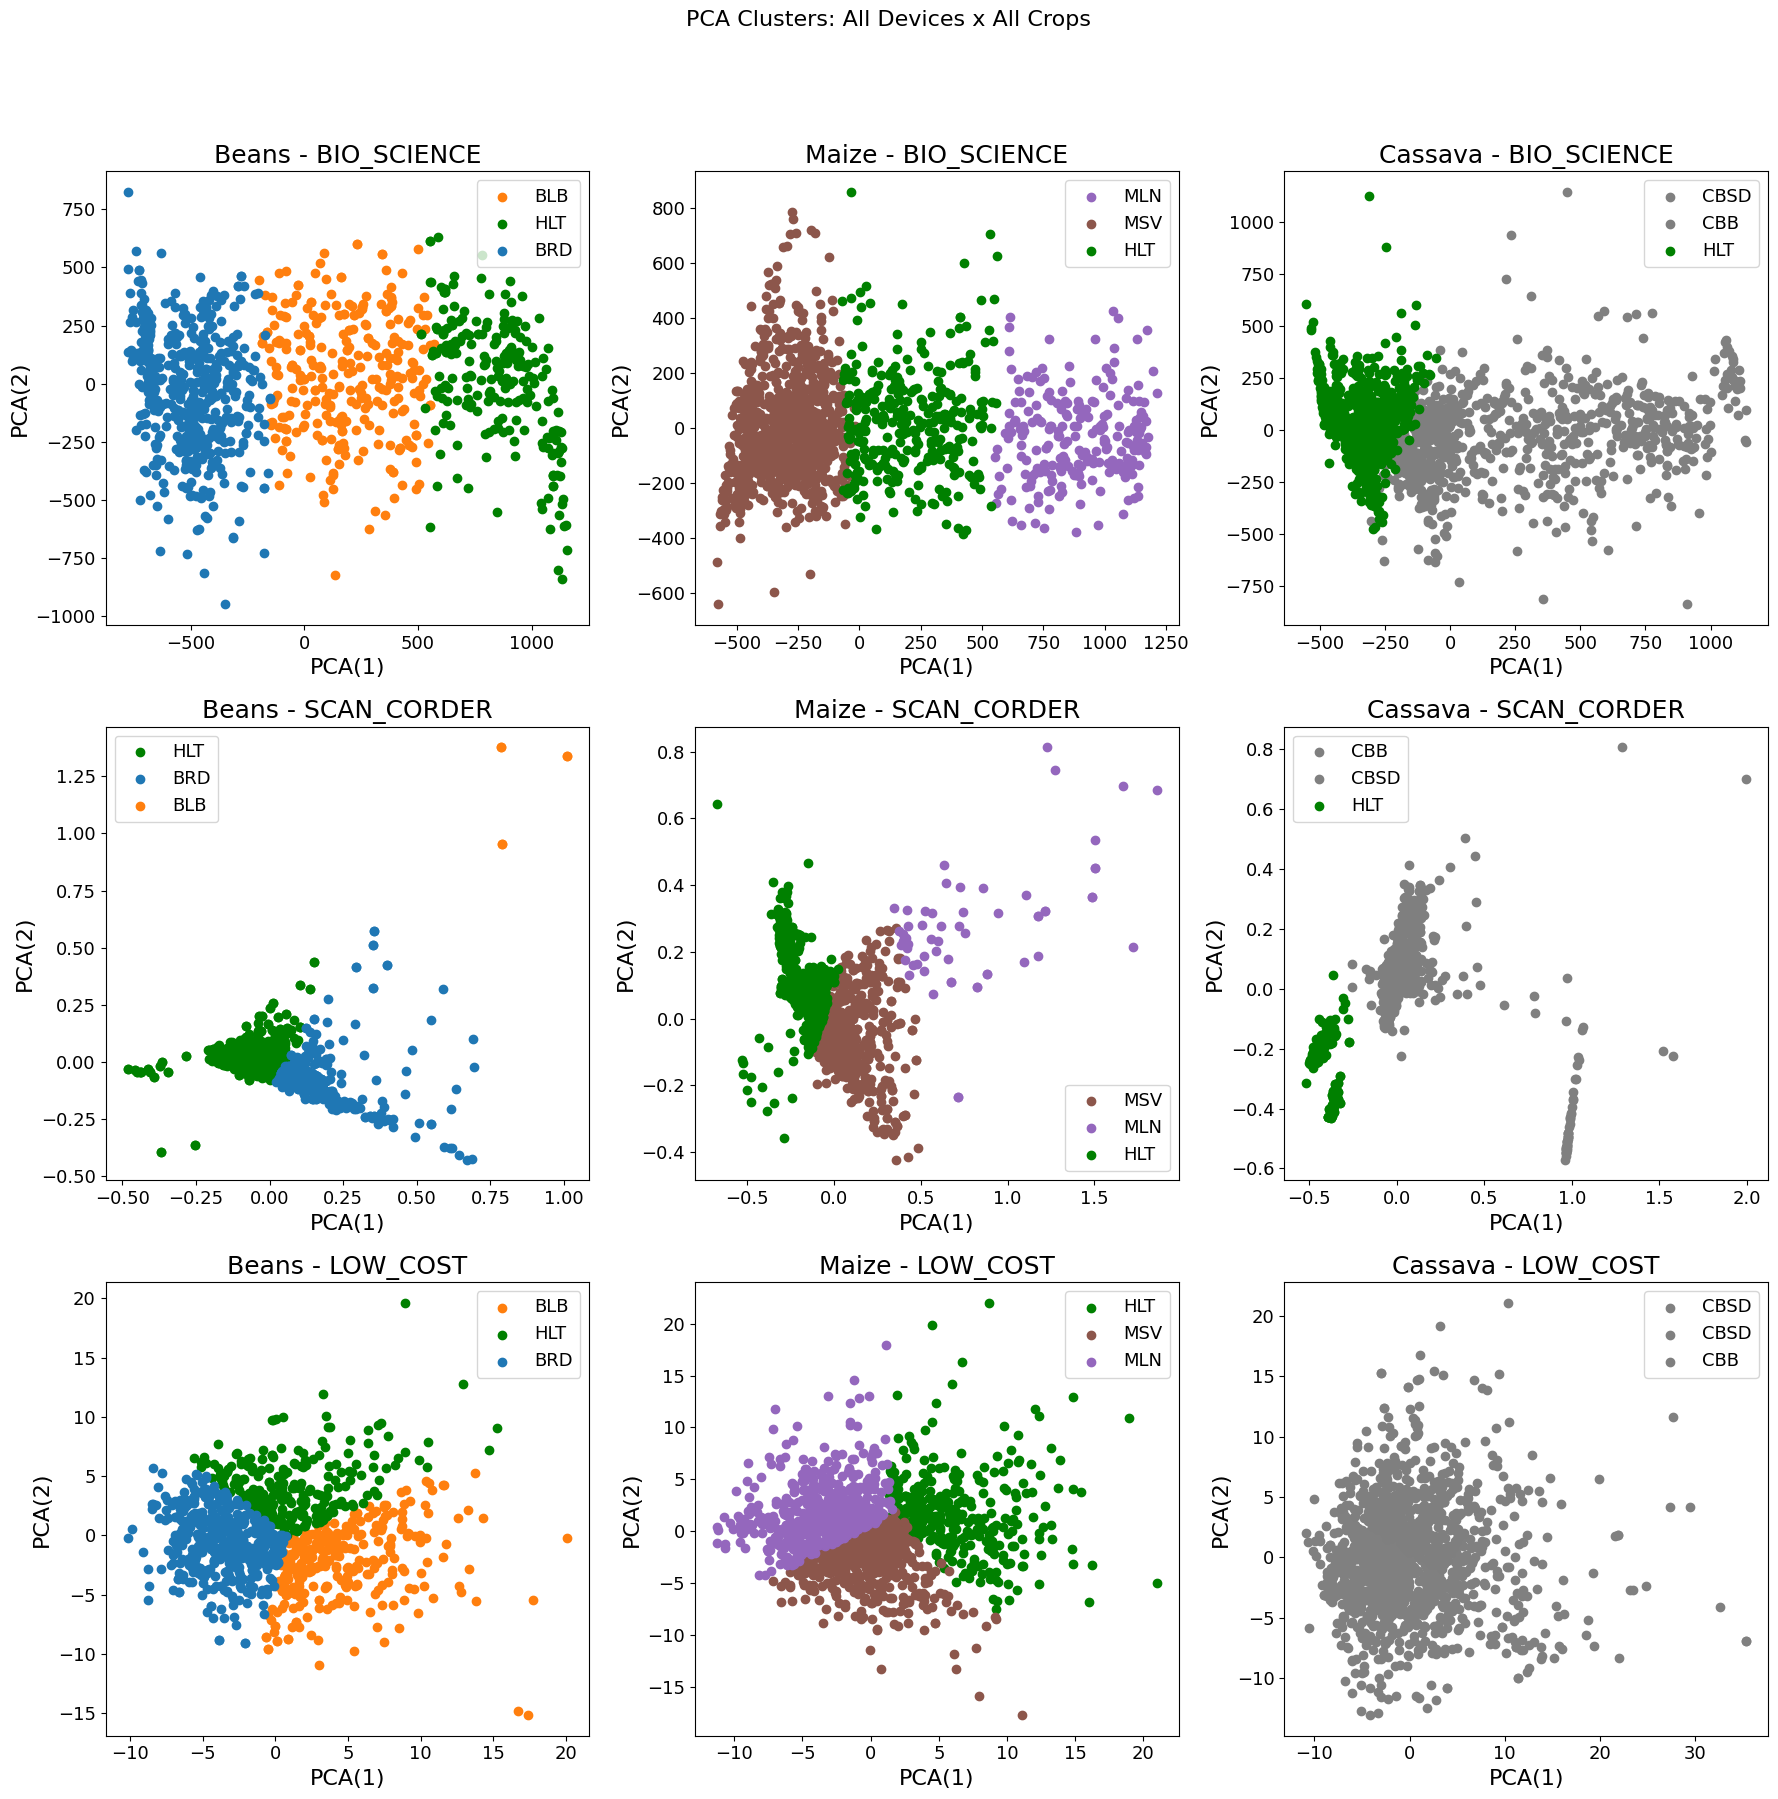

In [25]:
def generate_all_devices_plot(out_dir="."):
    """
    Produces ONE figure containing every device x crop combination:
    rows = devices (BIO_SCIENCE, SCAN_CORDER, LOW_COST)
    cols = crops   (Beans, Maize, Cassava)
    Saved to: {out_dir}/all_devices_pca_clusters_combined.png
    """
    devices = Device.get_devices()
    crop_name_list = list(CROP_NAMES.keys())
    CROP_FULL_NAMES = {'B': 'Beans', 'M': 'Maize', 'C': 'Cassava'}

    fig, ax = plt.subplots(len(devices), len(crop_name_list), figsize=(6 * len(crop_name_list), 6 * len(devices)))

    for row, device in enumerate(devices):
        cluster_state = generate_crop_clusters(device)

        for col, crop in enumerate(cluster_state.keys()):
            state = cluster_state[crop]
            x_pca = state['pcas']
            labels = state['labels']
            true_labels = state['true_classes']

            cluster_dict = {}
            for label in np.unique(labels):
                mask_idx = (labels == label)
                pred_classes = true_labels[mask_idx]
                majority_class = Counter(pred_classes).most_common(1)[0][0]
                cluster_dict[label] = majority_class.astype(np.int32)

            axis = ax[row][col]
            for label in np.unique(labels):
                cluster_mask = (labels == label)
                class_name = class_codes_dict[cluster_dict[label]]
                if class_name not in CLASS_COLOR_MAP:
                    print(f"Warning: '{class_name}' has no entry in CLASS_COLOR_MAP, using gray")
                axis.scatter(
                    x_pca[cluster_mask, 0], x_pca[cluster_mask, 1],
                    label=class_name,
                    color=CLASS_COLOR_MAP.get(class_name, 'gray')
                )
            axis.set_title(f'{CROP_FULL_NAMES[crop_name_list[crop]]} - {device.name}')
            axis.set_xlabel('PCA(1)'); axis.set_ylabel('PCA(2)')
            axis.legend(frameon=True, loc='best')

    fig.suptitle('PCA Clusters: All Devices x All Crops', fontsize=16, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    combined_path = f"{out_dir}/all_devices_pca_clusters_combined.png"
    fig.savefig(combined_path, dpi=300)
    print(f"Saved all-devices combined figure -> {os.path.abspath(combined_path)}")
    plt.show()


if __name__ == '__main__':
    generate_all_devices_plot()

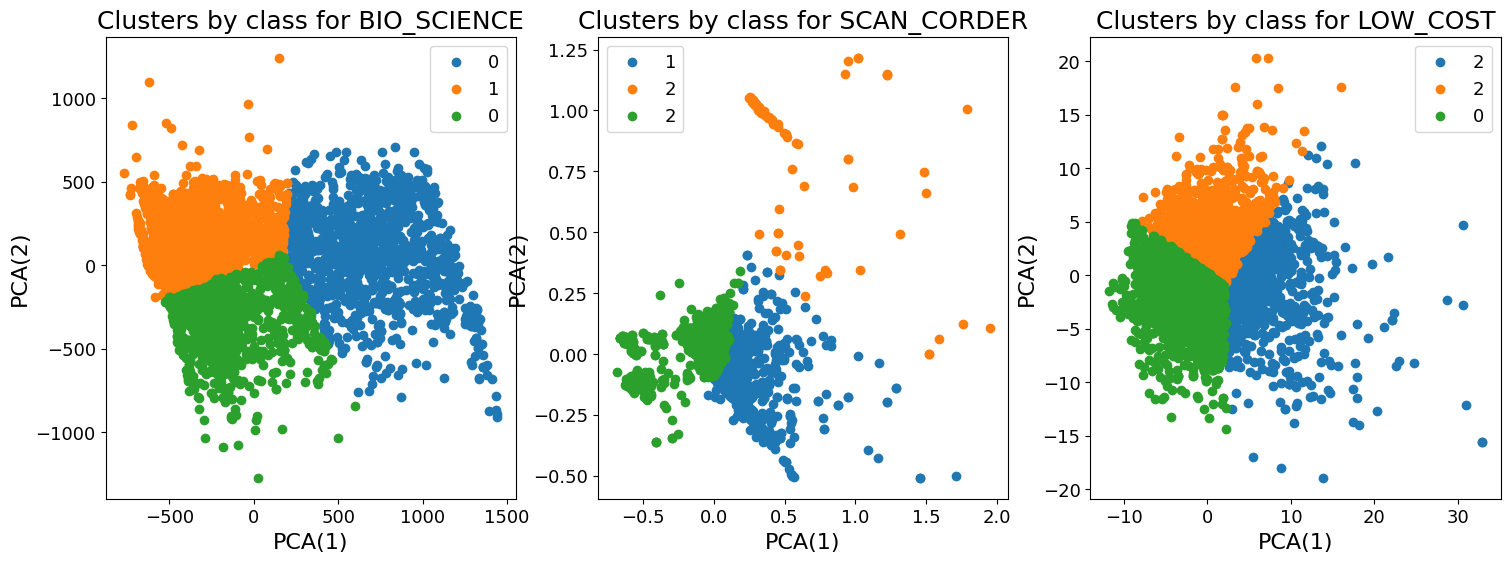

In [26]:
def cluster_by_crops(device):
    x, y, wl, class_codes = load_device(device)

    y = transform_y(y, class_codes)
    if device == Device.SCAN_CORDER:
        bf = Bound_Outlier_Filter(-0.5, 2.0)
        x, y = bf.forward(x, y)
        
    # Manage class imbalances
    smote = SMOTE(random_state=42)
    x_balanced, true_classes_balanced = smote.fit_resample(x, y[: , -3])
        
    kmeans = KMeans(n_clusters= 3, random_state=0)
    kmeans.fit(x_balanced)
    labels = kmeans.labels_
    
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x_balanced)
    return {'x': x_pca, 'labels': labels, 'true_classes': true_classes_balanced}


if __name__ == '__main__':
    state = {}
    for device in Device.get_devices():
        result_idx = cluster_by_crops(device)
        state[device.name] = result_idx
    # visualization of the cluster information
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax = ax.flatten()
    
    for i, device_name in enumerate(state.keys()):
        state_idx = state[device_name]
        x_pca = state_idx['x']
        labels = state_idx['labels']
        true_labels = state_idx['true_classes']
        
        cluster_dict = {}
        unique_labels = np.unique(labels)
        for label in unique_labels:
            mask_idx = (labels == label)
            pred_classes = true_labels[mask_idx]
            majority_class = Counter(pred_classes).most_common(1)[0][0]
            cluster_dict[label] = majority_class.astype(np.int32) 
        
        for label in unique_labels:
            cluster_mask = (labels == label)
            ax[i].scatter(x_pca[cluster_mask, 0], x_pca[cluster_mask, 1], label=f'{cluster_dict[label]}')

        # ax[i].scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
        ax[i].set_xlabel('PCA(1)'); ax[i].set_ylabel('PCA(2)')
        ax[i].set_title(f'Clusters by class for {device_name}')
        ax[i].legend(frameon=True, loc='best')
    plt.show()